In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy
import torch
import torch.nn as nn

import pymc
from magnus import NSFeas
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "plots" / "tools"))
from trellis import trellis_plot #pyright:ignore
from corner import corner_plot #pyright:ignore

In [4]:
# Helpers
def theta_nominal():
    T_REF = 328.15
    k_1_ref = 8.84e-3 * 60 * 0.5 # 1/min
    k_2_ref = k_1_ref / 8
    theta_1 = k_1_ref * np.exp(E_1 / (R_GAS * T_REF))
    theta_2 = k_2_ref * np.exp(E_2 / (R_GAS * T_REF))

    return theta_1, theta_2

In [5]:
# Global Constants
E_1 = 48_000 # J/mol (activation energy first reaction)
E_2 = 55_000 # J/mol (activation energy second reaction)
R_GAS = 8.314 # J/K/mol
th_1, th_2 = theta_nominal()
BENZENE_FEED_CONC = 11.28e3 # mol/m3

In [6]:
# Calculation of arrhenius prefactors (T-dependent)

def compute_k(T_1: float, T_2: float):
    k_1_R1 = th_1 * np.exp(- E_1 / (R_GAS * T_1))
    k_2_R1 = th_2 * np.exp(- E_2 / (R_GAS * T_1))
    k_1_R2 = th_1 * np.exp(- E_1 / (R_GAS * T_2))
    k_2_R2 = th_2 * np.exp(- E_2 / (R_GAS * T_2))

    return (k_1_R1, k_2_R1), (k_1_R2, k_2_R2)

In [7]:
# Counters (for stat purposes only)
M1_counter = R1_counter = R2_counter = S1_counter = 0

In [8]:
# Mixer
def M1(rho: float, c_R: tuple, c_F: tuple):
    global M1_counter; M1_counter += 1
    c_A_R, c_B_R, c_C_R = c_R[0], c_R[1], c_R[2]
    c_A_F, c_B_F, c_C_F = c_F[0], c_F[1], c_F[2]
    c_A_alpha = rho * c_A_R + (1 - rho) * c_A_F
    c_B_alpha = rho * c_B_R + (1 - rho) * c_B_F
    c_C_alpha = rho * c_C_R + (1 - rho) * c_C_F

    return c_A_alpha, c_B_alpha, c_C_alpha

In [9]:
# CSTR1
def R1(c_alpha: tuple, k_R1: tuple, tau_1: float):
    global R1_counter; R1_counter += 1
    k_1_R1, k_2_R1 = k_R1[0], k_R1[1]
    c_A_alpha, c_B_alpha, c_C_alpha = c_alpha[0], c_alpha[1], c_alpha[2]

    c_A_R1 = c_A_alpha / (1 + k_1_R1 * tau_1)
    c_B_R1 = (c_B_alpha + k_1_R1 * c_A_R1 * tau_1) / (1 + k_2_R1 * tau_1)
    c_C_R1 = c_C_alpha + k_2_R1 * c_B_R1 * tau_1
    
    return c_A_R1, c_B_R1, c_C_R1

In [10]:
# CSTR2
def R2(c_R1: tuple, k_R2: tuple, tau_2: float):
    global R2_counter; R2_counter += 1
    c_A_R1, c_B_R1, c_C_R1 = c_R1[0], c_R1[1], c_R1[2]
    k_1_R2, k_2_R2 = k_R2[0], k_R2[1]

    c_A_R2 = c_A_R1 / (1 + k_1_R2 * tau_2)
    c_B_R2 = (c_B_R1 + k_1_R2 * c_A_R2 * tau_2) / (1 + k_2_R2 * tau_2)
    c_C_R2 = c_C_R1 + k_2_R2 * c_B_R2 * tau_2

    return c_A_R2, c_B_R2, c_C_R2

In [11]:
# Splitter
def S1(c_R2: tuple):
    # NOTE: rho: recycle ratio, dens: density
    global S1_counter; S1_counter += 1
    c_A_R2, c_B_R2, c_C_R2 = c_R2[0], c_R2[1], c_R2[2]
    M_A, M_B, M_C = 78.11, 112.56, 147.00 # g/mol
    dens_A, dens_B, dens_C = 0.88e6, 1.11e6, 1.30e6 # g/m3
    s_A, s_B, s_C = 0.7, 0.35, 0.20 # these values are for illustration
    summands = [M_A / dens_A  * s_A * c_A_R2, M_B / dens_B  * s_B * c_B_R2, M_C / dens_C  * s_C * c_C_R2]
    rho = sum(summands)
    c_A_R = s_A * c_A_R2 / rho
    c_B_R = s_B * c_B_R2 / rho
    c_C_R = s_C * c_C_R2 / rho

    return (c_A_R, c_B_R, c_C_R), rho

In [12]:
def get_informed_guess():
    """Make informed initial guess by finding nearest feasible configuration
    First value: is informed guess available (NONE if no feasible points found yet),
    Second value: rho_ig,
    Third value: c_R_ig
    TODO: implement this if fixed point iterations are slow
    """
    return None, None, None

In [13]:
def is_converged(c_R_real_guess, rho_real_guess):
    """Takes in tuples of real and guessed values for c_R 
    (recycle stream concentration), and rho (recycle ratio)
    and compares them."""
    (c_A_R_real, c_B_R_real, c_C_R_real), (c_A_R_guess, c_B_R_guess, c_C_R_guess) = c_R_real_guess
    rho_real, rho_guess = rho_real_guess
    real = np.array([c_A_R_real, c_B_R_real, c_C_R_real, rho_real])
    guess = np.array([c_A_R_guess, c_B_R_guess, c_C_R_guess, rho_guess])
    diff = np.abs(real - guess)
    diff_norm = diff / (np.absolute(real) + 1e-8)
    max_vio = diff_norm.max()

    return max_vio < 1e-3

In [14]:
class SimResult:
    def __init__(self, converged, c_alpha, c_R1, c_R2, c_R, rho, c_F):
        self.converged = converged
        self.c_alpha = c_alpha
        self.c_R1 = c_R1
        self.c_R2 = c_R2
        self.c_R = c_R
        self.c_F = c_F
        self.rho = rho

In [15]:
# Simulate forward (to be called by Nested Sampler)
def sim_forward_real(T_1, tau_1, T_2, tau_2):
    it, MAX_ITER = 0, 1000
    c_F = BENZENE_FEED_CONC, 0, 0 # mol/m3 (pure benzene feed)
    # initial guesses (ig)
    inf_guess = get_informed_guess()
    rho_ig = 0.3 if not inf_guess[0] else inf_guess[1]
    c_R_ig = (5e3, 2e3, 1e3) if not inf_guess[0] else inf_guess[2]

    # k need fresh computatation at each configuration (T-dependent)
    k_R1, k_R2 = compute_k(T_1, T_2)

    while (it < MAX_ITER):
        it += 1
        c_alpha = M1(rho=rho_ig, c_R=c_R_ig, c_F=c_F)
        c_R1 = R1(c_alpha=c_alpha, k_R1=k_R1, tau_1=tau_1)
        c_R2 = R2(c_R1=c_R1, k_R2=k_R2, tau_2=tau_2)
        c_R, rho = S1(c_R2=c_R2)
        conv = is_converged((c_R, c_R_ig), (rho, rho_ig))
        if conv:
            # NOTE: return guess not result
            return SimResult(converged=True, c_alpha=c_alpha,
                             c_R1=c_R1, c_R2=c_R2,
                             c_R=c_R, c_F=c_F, rho=rho)

        # update to next tear iteration
        c_R_ig, rho_ig = c_R, rho

    # not converged within MAX_ITER
    return SimResult(False, None, None, None, None, None, None)

In [16]:
# Interface Adapter for real unit operations
def model_simultaneous_real(x):
    """Model of CSTR-cascade flowsheet using acutal unit operations."""
    T_1, tau_1, T_2, tau_2 = x[0], x[1], x[2], x[3]
    sim_res = sim_forward_real(T_1=T_1, tau_1=tau_1, T_2=T_2, tau_2=tau_2)

    if not sim_res.converged or sim_res.rho < 0 or sim_res.rho > 1:
        # return *something* guaranteed to be infeasible
        return [-1e-8, -1e-8, -1e-8, -1e-8, -1e-8, -1e-8]
    c_A_R1, c_B_R1, c_C_R1 = sim_res.c_R1[0], sim_res.c_R1[1], sim_res.c_R1[2] 
    c_A_R2, c_B_R2, c_C_R2 = sim_res.c_R2[0], sim_res.c_R2[1], sim_res.c_R2[2] 

    return [c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2]

In [17]:
def simultaneous_NS(model, numlive=8192, numprop=256):
    """Performs nested sampling on entire search space"""
    # Nested Sampling of [T1, tau1, T2, tau2] space
    DAG = pymc.FFGraph()
    DAG.options.MAXTHREAD = 1

    T_1, tau_1 = DAG.add_var('T_1'), DAG.add_var('tau_1')
    T_2, tau_2 = DAG.add_var('T_2'), DAG.add_var('tau_2')

    op = pymc.FFCustom()
    op.set_D_eval(model)
    # applying the operation adds nodes to DAG
    outs = op(ndep=6, var=[T_1, tau_1, T_2, tau_2], uid=0)
    c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2 = outs[0], outs[1], outs[2], outs[3], outs[4], outs[5]

    # Setup nested sampler
    NS = NSFeas()
    NS.options.MAXTHREAD = 1           # Python callback + GIL: must be 1
    NS.options.DISPLEVEL = 1           # console verbosity
    NS.options.DISPITER  = 25          # rows per N iterations in table (cosmetic)
    NS.options.NUMLIVE   = numlive     # #Live Points
    NS.options.NUMPROP   = numprop     # Proposals per iteration
    NS.options.MAXITER   = 0           # iterate until complete (hard iteration limit else)

    NS.set_dag(DAG)
    # contols for variables and bounds
    NS.set_control([T_1, tau_1, T_2, tau_2], [298.15, 2, 298.15, 2], [353.15, 30, 353.15, 30])
    NS.set_constraint([c_C_R1 / (c_A_R1 + c_B_R1 + c_C_R1) - 0.05,
                    0.55 - c_B_R2 / (c_A_R2 + c_B_R2 + c_C_R2), 
                    0.70 - (1 - c_A_R2 / BENZENE_FEED_CONC)])
    NS.setup()
    NS.sample()
    NS.stats.display()
    # assert M1_counter == R1_counter == R2_counter == S1_counter and M1_counter != 0
    return NS

NS_simultaneous = simultaneous_NS(model_simultaneous_real)


** INITIALIZING LIVE POINTS (8192)      0.42 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.6639e-01   103        0     3.0000e-01
     25     3.1804e-01   180     4744     2.6720e-01
     50     2.1590e-01   267     7711     2.4853e-01
     75     1.6380e-01   348     9876     2.3573e-01
    100     1.3188e-01   438    11595     2.2604e-01
    125     1.1174e-01   522    13018     2.1832e-01
    150     9.5777e-02   614    14268     2.1176e-01
    175     8.4120e-02   707    15382     2.0608e-01
    200     7.4876e-02   795    16398     2.0103e-01
    225     6.7730e-02   889    17289     1.9671e-01
    250     6.1479e-02   988    18136     1.9268e-01
    275     5.6028e-02  1083    18910     1.8907e-01
    300     5.1590e-02  1186    19648     1.8570e-01
    325     4.5279e-02  1350    20689     1.8104e-01
    350     3.8242e-02  1577    21991     1.7537e-01
    375     3.2806e-02  1823    23186     1.7033

In [18]:
print("M1:", M1_counter, "R1:", R1_counter, "R2:", R2_counter, "S1:", S1_counter)
# reset counters
M1_counter = R1_counter = R2_counter = S1_counter = 0

M1: 909480 R1: 909480 R2: 909480 S1: 909480


panel counts (rows = $\tau_2$ [min] high->low, cols = $\tau_1$ [min] low->high):
[[ 7071  2574  1776]
 [ 9259  3160  1972]
 [11201  4293  2322]]
sum of panels = 43628   total points = 43628


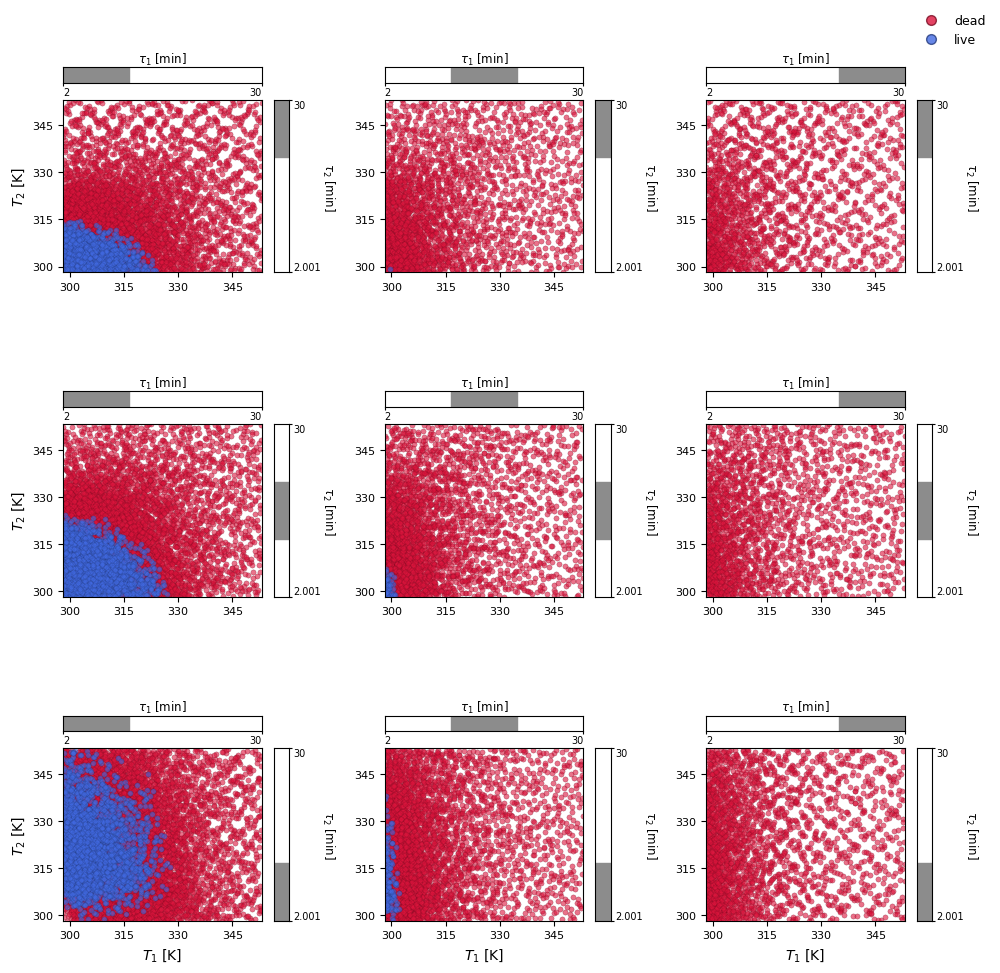

In [19]:
def simultaneous_trellis_plot():
    # NS.livepoints returns: (points[N, nu],  crit[N, 1],  prob[N, 1],  aux[N, 1])
    live_pts, live_feas, *_ = NS_simultaneous.live_points
    dead_pts, dead_feas, *_ = NS_simultaneous.dead_points

    fig = trellis_plot(
        [dead_pts[:, 0], live_pts[:, 0]],   # T_1
        [dead_pts[:, 2], live_pts[:, 2]],   # T_2
        [dead_pts[:, 1], live_pts[:, 1]],   # tau_1
        [dead_pts[:, 3], live_pts[:, 3]],   # tau_2
        x_label="$T_1$ [K]",
        y_label=r"$T_2$ [K]",
        col_label=r"$\tau_1$ [min]",
        row_label=r"$\tau_2$ [min]",
        colors=["crimson", "royalblue"],
        labels=["dead", "live"],
    )

simultaneous_trellis_plot()

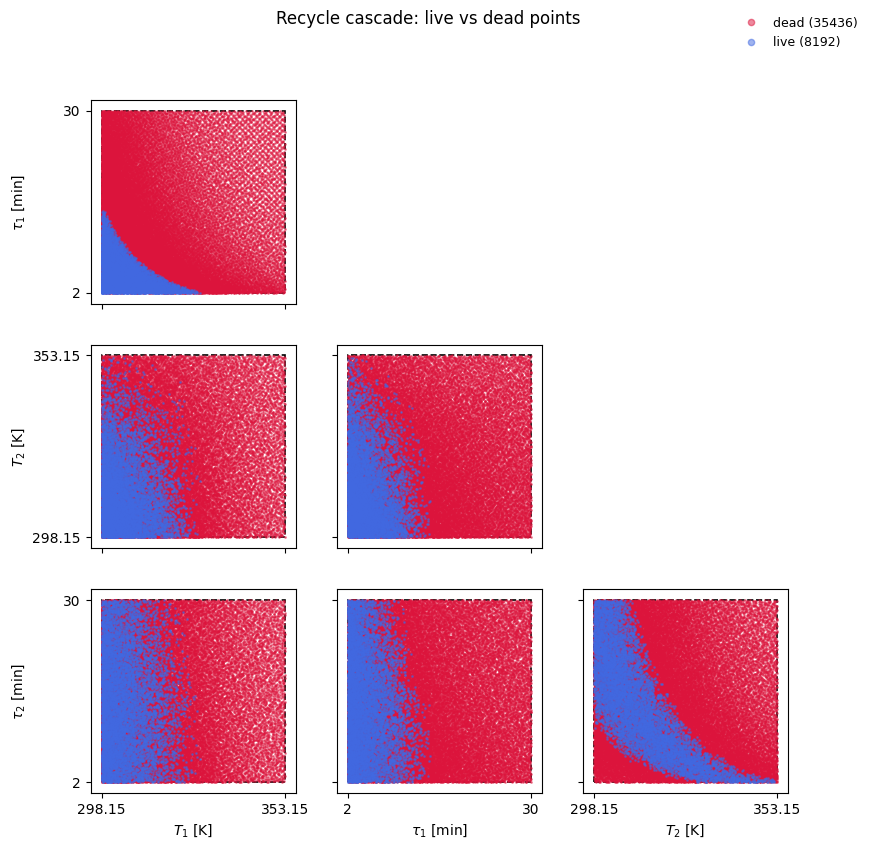

In [20]:
def simultaneous_corner_plot():
    live_pts, live_feas, *_ = NS_simultaneous.live_points
    dead_pts, dead_feas, *_ = NS_simultaneous.dead_points
    fig = corner_plot(
        [  # painter's order: dead below, live (feasible) on top
            dict(data=dead_pts, color="crimson", ms=2, alpha=0.5, label=f"dead ({len(dead_pts)})"),
            dict(data=live_pts, color="royalblue", ms=2, alpha=0.5, label=f"live ({len(live_pts)})"),
        ],
        labels=[r"$T_1$ [K]", r"$\tau_1$ [min]", r"$T_2$ [K]", r"$\tau_2$ [min]"],
        bounds=[(298.15, 353.15), (2, 30), (298.15, 353.15), (2, 30)],
        legend=True,
        title=r"Recycle cascade: live vs dead points",
    )

simultaneous_corner_plot()

# Decomposition based sampling

### Inlet Bounds Generation

In [21]:
def generate_sobol_points(n: int, bounds):
    """
    n: number of points to sample
    """
    d = bounds.shape[1]
    m = int(np.ceil(np.log2(n)))
    sbsam = scipy.stats.qmc.Sobol(d=d, seed=42)
    rand_norm = sbsam.random_base2(m=m) # 2^m points
    pts = rand_norm * (bounds[1] - bounds[0]) + bounds[0]
    return pts[:n]

In [22]:
def initialize_search_space():
    k_bounds = np.array([[298.15, 2, 298.15, 2], [353.15, 30, 353.15, 30]]) # T1, tau1, T2, tau2
    v_train = generate_sobol_points(40, k_bounds)
    results = {}
    for point in v_train:
        T_1, tau_1, T_2, tau_2 = point[0], point[1], point[2], point[3]
        results[tuple(point)] = sim_forward_real(T_1=T_1, tau_1=tau_1, T_2=T_2, tau_2=tau_2)
    return results
initialization_results = initialize_search_space()

In [23]:
# bounds for KU_i
class UnitOpBounds:
    def __init__(self, unit_name):
        self.unit_name = unit_name
        self.bounds = {}
    def add(self, var: str):
        self.bounds[var] = [float('inf'), float('-inf')] # lb, ub
    def update(self, var, val):
        assert var in self.bounds
        self.bounds[var] = [min(self.bounds[var][0], val), max(self.bounds[var][1], val)]
    def inflate(self, infl):
        """inflates by infl symmetrically, clamping at zero"""
        for b in self.bounds.values():
            span = b[1] - b[0]
            b[0], b[1] = max(b[0] - infl * span, 0), b[1] + infl * span

In [24]:
# Note: m1 has four inputs
m1_init_bounds = UnitOpBounds('M1')
m1_init_bounds.add('rho')
m1_init_bounds.add('c_A_R')
m1_init_bounds.add('c_B_R')
m1_init_bounds.add('c_C_R')

r1_init_bounds = UnitOpBounds('R1')
r1_init_bounds.add('c_A_alpha')
r1_init_bounds.add('c_B_alpha')
r1_init_bounds.add('c_C_alpha')

r2_init_bounds = UnitOpBounds('R2')
r2_init_bounds.add('c_A_R1')
r2_init_bounds.add('c_B_R1')
r2_init_bounds.add('c_C_R1')

s1_init_bounds = UnitOpBounds('S1')
s1_init_bounds.add('c_A_R2')
s1_init_bounds.add('c_B_R2')
s1_init_bounds.add('c_C_R2')

In [25]:
for v in initialization_results.values():
    m1_init_bounds.update('c_A_R', v.c_R[0])
    m1_init_bounds.update('c_B_R', v.c_R[1])
    m1_init_bounds.update('c_C_R', v.c_R[2])
    m1_init_bounds.update('rho', v.rho)

    r1_init_bounds.update('c_A_alpha', v.c_alpha[0])
    r1_init_bounds.update('c_B_alpha', v.c_alpha[1])
    r1_init_bounds.update('c_C_alpha', v.c_alpha[2])

    r2_init_bounds.update('c_A_R1', v.c_R1[0])
    r2_init_bounds.update('c_B_R1', v.c_R1[1])
    r2_init_bounds.update('c_C_R1', v.c_R1[2])

    s1_init_bounds.update('c_A_R2', v.c_R2[0])
    s1_init_bounds.update('c_B_R2', v.c_R2[1])
    s1_init_bounds.update('c_C_R2', v.c_R2[2])

# inflate bounds
m1_init_bounds.inflate(0.15)
r1_init_bounds.inflate(0.15)
r2_init_bounds.inflate(0.15)
s1_init_bounds.inflate(0.15)

### Unit Op ANN training template

In [26]:
# ANN training template
class Surrogate:
    """Plain-numpy MLP: scaling folded into first/last layer"""
    def __init__(self, W, b):
        self.W, self.b = W, b

    def __call__(self, x):
        x = np.asarray(x, dtype=float)
        single = x.ndim == 1
        h = np.atleast_2d(x)
        for i, (Wl, bl) in enumerate(zip(self.W, self.b)):
            h = h @ Wl.T + bl
            if i + 1 < len(self.W):
                h = np.tanh(h)
        return h[0] if single else h

    def export(self, path):
        with open(path, "w") as f:
            f.write(f"{len(self.W)}\n")
            for Wl, bl in zip(self.W, self.b):
                f.write(f"{Wl.shape[1]} {Wl.shape[0]}\n")
                for row in Wl:
                    f.write(" ".join(f"{v:.17g}" for v in row) + "\n")
                f.write(" ".join(f"{v:.17g}" for v in bl) + "\n")

In [27]:
def fit_surrogate(X, Y, hid=16, epochs=3000, lr=1e-3, seed=0, verbose=True):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    if Y.ndim == 1:
        Y = Y[:, None]                       # tolerate 1-D targets
    torch.manual_seed(seed)

    xmu, xsig = X.mean(0), X.std(0) + 1e-12
    ymu, ysig = Y.mean(0), Y.std(0) + 1e-12
    tx = torch.tensor((X - xmu) / xsig, dtype=torch.float64)
    ty = torch.tensor((Y - ymu) / ysig, dtype=torch.float64)

    net = nn.Sequential(
        nn.Linear(X.shape[1], hid), nn.Tanh(),
        nn.Linear(hid, hid), nn.Tanh(),
        nn.Linear(hid, Y.shape[1]),
    ).double()
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for ep in range(epochs):
        opt.zero_grad()
        loss = nn.functional.mse_loss(net(tx), ty)
        loss.backward()
        opt.step()
        if verbose and ep % 500 == 0:
            print(f"  epoch {ep:5d} mse(std) {loss.item():.3e}")

    # fold standardization into affine layers -> raw-unit in, raw-unit out
    lins = [m for m in net if isinstance(m, nn.Linear)]
    W = [m.weight.detach().numpy().copy() for m in lins]
    b = [m.bias.detach().numpy().copy() for m in lins]
    b[0] = b[0] - W[0] @ (xmu / xsig)
    W[0] = W[0] / xsig[None, :]
    W[-1] = ysig[:, None] * W[-1]
    b[-1] = ysig * b[-1] + ymu
    return Surrogate(W, b)

### Nested Sampling Per Unit

In [28]:
def nested_sample_unit(box, unit_model, n_out, make_constraints,
                       uid, n_live, n_prop, verbose=False):
    """Nested-sample one unit over `box` and record ALL evaluations.
    box:              dict var_name -> [lb, ub]; ORDER defines x indexing!
    unit_model:       function x -> list of n_out outputs (plain floats)
    make_constraints: function outs (FFVars) -> list of constraints (feasible <= 0)
    uid:              unique per FFCustom op in this kernel session
    Returns X (n, dim_in), Y (n, n_out) numpy arrays of every evaluation."""
    records_x = []
    records_y = []

    def recording_model(x):
        y = unit_model(x)
        records_x.append(list(x))
        records_y.append(list(y))
        return y

    var_names, lb, ub = [], [], []
    for vname, bnd in box.items():
        var_names.append(vname)
        lb.append(bnd[0])
        ub.append(bnd[1])

    DAG = pymc.FFGraph()
    DAG.options.MAXTHREAD = 1
    ffvars = []
    for vname in var_names:
        ffvars.append(DAG.add_var(vname))

    op = pymc.FFCustom()
    op.set_D_eval(recording_model)
    outs = op(ndep=n_out, var=ffvars, uid=uid)

    NS = NSFeas()
    NS.options.MAXTHREAD = 1       # Python callback + GIL
    NS.options.DISPLEVEL = 1 if verbose else 0
    NS.options.DISPITER  = 25
    NS.options.NUMLIVE   = n_live
    NS.options.NUMPROP   = n_prop
    NS.options.MAXITER   = 0
    NS.set_dag(DAG)
    NS.set_control(ffvars, lb, ub)
    NS.set_constraint(make_constraints(outs))
    NS.setup()
    NS.sample()
    NS.stats.display()

    return np.array(records_x), np.array(records_y)

In [29]:
# Modeling M1
def generate_train_data_M1():
    """Generates training data for unit M1, based on sobol sampled points within bounds,
    note there is no feasibility constraints on this unit. Hence nested sampling is replaced with Sobol
    sampling"""
    bounds = m1_init_bounds.bounds
    m1_sampling_bounds = np.array([[bounds['rho'][0], bounds['c_A_R'][0], bounds['c_B_R'][0], bounds['c_C_R'][0]], 
                                   [bounds['rho'][1], bounds['c_A_R'][1], bounds['c_B_R'][1], bounds['c_C_R'][1]]]) 
    inputs = generate_sobol_points(n=8192, bounds=m1_sampling_bounds)
    c_F = (BENZENE_FEED_CONC, 0, 0)

    records_x = []
    records_y = []

    for x in inputs:
        rho, c_A_R, c_B_R, c_C_R = x
        y = M1(rho=rho, c_R=(c_A_R, c_B_R, c_C_R), c_F=c_F)
        records_x.append(list(x))
        records_y.append(list(y))
    return np.array(records_x), np.array(records_y)

M1_training_data = generate_train_data_M1()

In [30]:
# Modeling R1
def R1_NS_wrap(x):
    T_1, tau_1, c_A_alpha, c_B_alpha, c_C_alpha = x
    k_R1 = compute_k(T_1, 42)[0]
    return R1(c_alpha=(c_A_alpha, c_B_alpha, c_C_alpha), k_R1=k_R1, tau_1=tau_1)

R1_training_data = nested_sample_unit(
    box={'T_1': [298.15, 353.15], 'tau_1': [2, 30], **r1_init_bounds.bounds},
    unit_model=R1_NS_wrap,
    n_out=3,
    # g1 constraint
    make_constraints=lambda outs: [outs[2] / (outs[0] + outs[1] + outs[2]) - 0.05],
    uid=42,
    n_live=8192,
    n_prop=256
)


** EVALUATIONS:     198400 (0 FAILED)
** WALL TIME:         7.75 SEC


In [31]:
# Modeling R2
def R2_NS_wrap(x):
    T_2, tau_2, c_A_R1, c_B_R1, c_C_R1 = x
    k_R2 = compute_k(42, T_2)[1]
    return R2(c_R1=(c_A_R1, c_B_R1, c_C_R1), k_R2=k_R2, tau_2=tau_2)

R2_training_data = nested_sample_unit(
    box={'T_2': [298.15, 353.15], 'tau_2': [2, 30], **r2_init_bounds.bounds},
    unit_model=R2_NS_wrap,
    n_out=3,
    # g2, g3 constraints
    make_constraints=lambda outs: [0.55 - outs[1] / (outs[0] + outs[1] + outs[2]),
                                   0.70 - (1 - (outs[0] / BENZENE_FEED_CONC))],
    uid=43,
    n_live=8192,
    n_prop=256
)


** EVALUATIONS:      61184 (0 FAILED)
** WALL TIME:         1.90 SEC


In [32]:
# Modeling S1
def generate_train_data_S1():
    """Generates training data for unit S1, based on sobol sampled points within bounds,
    note there is no feasibility constraints on this unit. Hence nested sampling is replaced with Sobol
    sampling"""
    bounds = s1_init_bounds.bounds
    s1_sampling_bounds = np.array([[bounds['c_A_R2'][0], bounds['c_B_R2'][0], bounds['c_C_R2'][0]], 
                                   [bounds['c_A_R2'][1], bounds['c_B_R2'][1], bounds['c_C_R2'][1]]]) 
    inputs = generate_sobol_points(n=8192, bounds=s1_sampling_bounds)

    records_x = []
    records_y = []

    for x in inputs:
        c_A_R2, c_B_R2, c_C_R2 = x
        y = S1(c_R2=(c_A_R2, c_B_R2, c_C_R2))
        records_x.append(list(x))
        records_y.append(list([*y[0], y[1]]))
    return np.array(records_x), np.array(records_y)

S1_training_data = generate_train_data_S1()

### Save ANN weights with hash

In [33]:
import hashlib
from pathlib import Path

def get_surrogate(name, X, Y):
    path = Path(f"../data/mlp_{name}.txt")
    h = hashlib.sha256(str(X.shape).encode() + np.ascontiguousarray(X, float).tobytes()
                     + np.ascontiguousarray(Y, float).tobytes()).hexdigest()
    if path.exists():
        tok = path.read_text().split()
        if tok[-1] == h: # rebuild Surrogate from file
            L, i, W, b = int(tok[0]), 1, [], []
            for _ in range(L):
                nin, nout = int(tok[i]), int(tok[i+1]); i += 2
                W.append(np.array(tok[i:i+nin*nout], float).reshape(nout, nin)); i += nin*nout
                b.append(np.array(tok[i:i+nout], float)); i += nout
            print(f"{name}: cached weights match data hash - loaded")
            return Surrogate(W, b)
    surr = fit_surrogate(X, Y)
    surr.export(str(path))
    with open(path, "a") as f:
        f.write(h + "\n")
    return surr

### Train ANN Surrogates On Sampled Data Per Unit

In [34]:
surr_M1 = get_surrogate("M1", *M1_training_data)

M1: cached weights match data hash - loaded


In [35]:
surr_R1 = get_surrogate("R1", *R1_training_data)

R1: cached weights match data hash - loaded


In [36]:
surr_R2 = get_surrogate("R2", *R2_training_data)

R2: cached weights match data hash - loaded


In [37]:
surr_S1 = get_surrogate("S1", *S1_training_data)

S1: cached weights match data hash - loaded


> Current working idea: Sample the `surrogate Flowsheet`, until ~SafetyFactor(e.g. 5)x `actual targeted number of feasible points` are found.
Then test the flowsheet with those points until number of required feasible points are validated and terminate.

In [38]:
# Surrogate version: simulate forward (to be called by Nested Sampler)
def sim_forward_surr(T_1, tau_1, T_2, tau_2):
    it, MAX_ITER = 0, 1000
    c_F = BENZENE_FEED_CONC, 0, 0 # mol/m3 (pure benzene feed)
    # initial guesses (ig)
    inf_guess = get_informed_guess()
    rho_ig = 0.3 if not inf_guess[0] else inf_guess[1]
    c_R_ig = (5e3, 2e3, 1e3) if not inf_guess[0] else inf_guess[2]

    while (it < MAX_ITER):
        it += 1
        c_alpha = surr_M1((rho_ig, *c_R_ig))
        c_R1 = surr_R1((T_1, tau_1, *c_alpha))
        c_R2 = surr_R2((T_2, tau_2, *c_R1))
        *c_R, rho = surr_S1(c_R2)
        conv = is_converged((c_R, c_R_ig), (rho, rho_ig))

        if conv:
            # NOTE: return guess not result
            return SimResult(converged=True, c_alpha=c_alpha,
                             c_R1=c_R1, c_R2=c_R2,
                             c_R=c_R, c_F=c_F, rho=rho)

        # update to next tear iteration
        c_R_ig, rho_ig = c_R, rho

    # not converged within MAX_ITER
    return SimResult(False, None, None, None, None, None, None)

In [39]:
# Interface Adapter for surrogate unit operations
def model_simultaneous_surr(x):
    """
    Model of CSTR-cascade flowsheet using surrogate unit operations.
    """
    T_1, tau_1, T_2, tau_2 = x[0], x[1], x[2], x[3]
    sim_res = sim_forward_surr(T_1=T_1, tau_1=tau_1, T_2=T_2, tau_2=tau_2)

    if not sim_res.converged or sim_res.rho < 0 or sim_res.rho > 1:
        # return *something* guaranteed to be infeasible
        return [-1e-8, -1e-8, -1e-8, -1e-8, -1e-8, -1e-8]
    c_A_R1, c_B_R1, c_C_R1 = sim_res.c_R1[0], sim_res.c_R1[1], sim_res.c_R1[2] 
    c_A_R2, c_B_R2, c_C_R2 = sim_res.c_R2[0], sim_res.c_R2[1], sim_res.c_R2[2] 

    return [c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2]

In [40]:
NS_simultaneous_surr = simultaneous_NS(model_simultaneous_surr, numlive=8192 * 2, numprop=1024)


** INITIALIZING LIVE POINTS (16384)      4.59 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.5755e-01   202        0     3.0000e-01
     25     2.1696e-01   547    15441     2.4847e-01
     50     1.3124e-01   892    23267     2.2583e-01
     75     9.3462e-02  1257    28898     2.1083e-01
    100     7.2243e-02  1653    33317     1.9976e-01
    125     5.8067e-02  2060    37072     1.9081e-01
    150     4.1903e-02  2916    42574     1.7841e-01
    175     2.9971e-02  4059    47855     1.6727e-01
    200     2.0982e-02  5481    52858     1.5736e-01
    225     1.3908e-02  7359    57638     1.4844e-01
    250     8.1672e-03  9776    62284     1.4026e-01
    275     3.7597e-03 12659    66485     1.3325e-01
    300     1.1934e-04 16246    70581     1.2675e-01
    302    -8.7633e-06 16394    70729     1.2652e-01

** EVALUATIONS:     324608 (0 FAILED)
** WALL TIME:        93.92 SEC


In [41]:
surr_candidates = NS_simultaneous_surr.live_points[0]

In [42]:
def constraints_satisfied(c_R1: tuple, c_R2: tuple) -> bool:
    c_A_R1, c_B_R1, c_C_R1 = c_R1
    c_A_R2, c_B_R2, c_C_R2 = c_R2
    g1 = c_C_R1 / (c_A_R1 + c_B_R1 + c_C_R1) - 0.05 <= 0
    g2 = 0.55 - c_B_R2 / (c_A_R2 + c_B_R2 + c_C_R2) <= 0 
    g3 = 0.70 - (1 - c_A_R2 / BENZENE_FEED_CONC)    <= 0
    if g1 and g2 and g3:
        return True
    return False

In [ ]:
# NOTE: If the candidates are in order all the candidates that get used eventually (less than the ones that are generated),
# will be *deep* inside the feasible region, and not at the boundary. Hence the boundary will be described poorly, in this case
# bands were observed. An optional way to mitigate is to use a permutation of the candidate set, it will however lead to a
# loss in boundary points.
surr_candidates_shuffled = np.random.default_rng(seed=42).permutation(surr_candidates, axis=0)

In [44]:
def validate_surr_cand_on_real_flowsheet():
    """
    Computes the feasible surrogate points on 
    real unit operations flowsheet. Stops when threshold is met
    """
    true_feas_set = []
    counter = 0
    for cand in surr_candidates_shuffled:
        if counter >= 8192:
            break
        sim_res = sim_forward_real(*cand)
        if (sim_res.converged):
            if (constraints_satisfied(c_R1=sim_res.c_R1, c_R2=sim_res.c_R2)):
                counter += 1
                true_feas_set.append(cand)
                
    return true_feas_set

true_feas_set_based_on_surrogate_fs = validate_surr_cand_on_real_flowsheet()

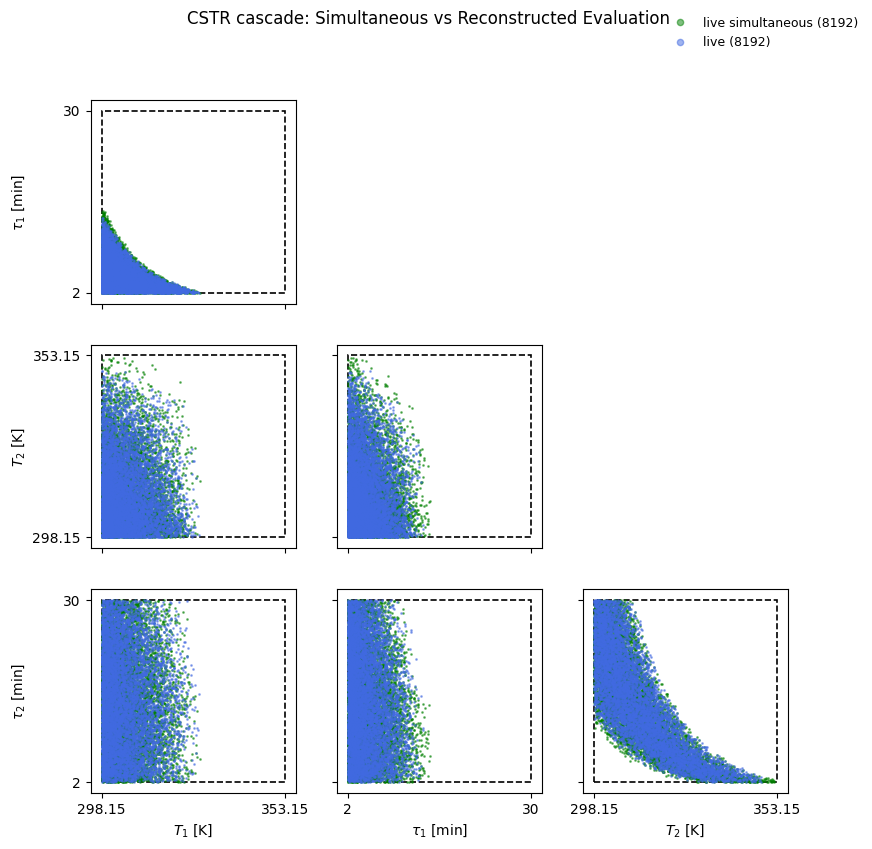

In [45]:
def simultaneous_reconstructed_corner_plot():
    live_pts = true_feas_set_based_on_surrogate_fs
    live_pts_simult, *_ = NS_simultaneous.live_points
    fig = corner_plot(
        [
            dict(data=live_pts_simult, color="green", ms=2, alpha=0.5, label=f"live simultaneous ({len(live_pts_simult)})"),
            dict(data=live_pts, color="royalblue", ms=2, alpha=0.5, label=f"live ({len(live_pts)})"),
        ],
        labels=[r"$T_1$ [K]", r"$\tau_1$ [min]", r"$T_2$ [K]", r"$\tau_2$ [min]"],
        bounds=[(298.15, 353.15), (2, 30), (298.15, 353.15), (2, 30)],
        legend=True,
        title=r"CSTR cascade: Simultaneous vs Reconstructed Evaluation",
    )

simultaneous_reconstructed_corner_plot()

In [46]:
print("M1:", M1_counter, "R1:", R1_counter, "R2:", R2_counter, "S1:", S1_counter)

M1: 55123 R1: 245331 R2: 108115 S1: 55123


In [49]:
def get_fraction_of_surrogate_true_feasibility():
    """
    Computes the fraction of the points suggested feasible by the
    surrogate flowsheet, that are actually feasible on real flowsheet
    """
    counter = 0
    for cand in surr_candidates:
        sim_res = sim_forward_real(*cand)
        if (sim_res.converged):
            if (constraints_satisfied(c_R1=sim_res.c_R1, c_R2=sim_res.c_R2)):
                counter += 1

    print("true feasible:", counter/len(surr_candidates))
                

get_fraction_of_surrogate_true_feasibility()

true feasible: 0.90643310546875
